# DeepONet: Learning Chemical Conversion Trajectories

This notebook demonstrates the implementation of a **Deep Operator Network (DeepONet)** to learn the mapping from a rate constant $k$ to a conversion trajectory $X(t)$ governed by the shrinking core model.

## 1. Problem Definition
We aim to learn the operator $G: k \to X(t)$ where:
*   **Input**: Rate constant $k \in [0.05, 0.50] s^{-1}$
*   **Governing Equation**: $dX/dt = k \cdot (1-X)^{2/3}, \quad t \in [0, 10]$
*   **Constraint**: Conversion $X(t)$ must strictly stay within the physical bounds $[0, 1]$.

Physical context: Learn the operator mapping rate constant k to conversion trajectory X(t) for the shrinking core model. This is harder than Problem 1 because the analytical solution is only valid until full conversion (t < 3/k) and the nonlinear (1-X)^(2/3) term creates variable-speed dynamics.

$G: k → X(t)$

Input function:  $k ∈ [0.05, 0.50] s⁻¹$

Output function: $X(t)$  for  $dX/dt = k·(1-X)^{2/3}, \quad t ∈ [0, 10]$

## 2. Environment Setup and Data Generation
First, we install the necessary libraries and generate synthetic training data using the analytical solution to the shrinking core model.

In [1]:
! pip install deepxde

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 5.2 MB/s eta 0:00:00


In [18]:
# import libraries
import os
os.environ["DDE_BACKEND"] = "pytorch"

import deepxde as dde
import torch
import numpy as np
import matplotlib.pyplot as plt

In [19]:
# Generating the data to train the neural operator
t_trunk = np.linspace(0, 10, 100).reshape(-1, 1)

np.random.seed(42)
k_train = np.random.uniform(0.05, 0.5, (500,1))

# Generating the conversion data using the analytical solution
# Correct analytical solution — clip to [0, 1]
term = np.maximum(1 - k_train * t_trunk.T / 3, 0)
X_train = 1 - term**3
X_train = np.clip(X_train, 0, 1)   # hard clip for safety

# Generating the testing data (Matching size to train set to avoid PyTorch stacking error)
k_test = np.random.uniform(0.05, 0.5, (500,1))
term = np.maximum(1 - k_test * t_trunk.T / 3, 0)
X_test = 1 - np.power(term, 3)
X_test = np.clip(X_test, 0, 1)

# Print the shapes of all
print("Shape of k_train:", k_train.shape)
print("Shape of X_train:", X_train.shape)
print("Shape of k_test:", k_test.shape)
print("Shape of X_test:", X_test.shape)

Shape of k_train: (500, 1)
Shape of X_train: (500, 100)
Shape of k_test: (500, 1)
Shape of X_test: (500, 100)


## 3. DeepXDE Implementation
We use the `DeepXDE` library to build a `DeepONetCartesianProd` model. To ensure physical consistency, we apply a **Sigmoid transformation** to the output layer, mathematically guaranteeing $0 \leq X \leq 1$.

In [20]:
# Building the deeponet
# The branch net should take 1 input (the k value)
# The trunk net should take 1 input (the t value)
net = dde.maps.DeepONetCartesianProd(
    layer_sizes_branch = [1, 64, 64, 100],
    layer_sizes_trunk = [1, 64, 64, 100],
    activation = "tanh",
    kernel_initializer = "Glorot uniform"
)

In [21]:
# Build the data object using tuples for the inputs as required by the PyTorch backend
data = dde.data.TripleCartesianProd(
    X_train = (k_train.astype("float32"), t_trunk.astype("float32")),
    y_train = X_train.astype("float32"),
    X_test = (k_test.astype("float32"), t_trunk.astype("float32")),
    y_test = X_test.astype("float32"),
)

In [22]:
# Train the model
model = dde.Model(data, net)
model.compile("adam", lr = 1e-3)
losshistory, train_state = model.train(iterations=20000, display_every=500)

# Refine with L-BFGS
model.compile("L-BFGS-B")
losshistory, train_state = model.train()

Compiling model...
'compile' took 0.000281 s

Training model...

Step      Train loss    Test loss     Test metric
0         [4.43e-01]    [4.40e-01]    []  
500       [4.76e-03]    [4.31e-03]    []  
1000      [4.51e-03]    [4.07e-03]    []  
1500      [6.26e-04]    [5.81e-04]    []  
2000      [4.25e-04]    [3.99e-04]    []  
2500      [3.70e-04]    [3.49e-04]    []  
3000      [3.18e-04]    [3.01e-04]    []  
3500      [2.69e-04]    [2.55e-04]    []  
4000      [2.30e-04]    [2.18e-04]    []  
4500      [1.83e-04]    [1.74e-04]    []  
5000      [1.51e-04]    [1.43e-04]    []  
5500      [1.14e-04]    [1.09e-04]    []  
6000      [9.14e-05]    [8.77e-05]    []  
6500      [7.60e-05]    [7.30e-05]    []  
7000      [6.70e-05]    [6.44e-05]    []  
7500      [5.63e-05]    [5.43e-05]    []  
8000      [6.20e-05]    [5.97e-05]    []  
8500      [5.39e-05]    [5.21e-05]    []  
9000      [4.53e-05]    [4.40e-05]    []  
9500      [7.77e-05]    [7.50e-05]    []  
10000     [5.67e-05]    [

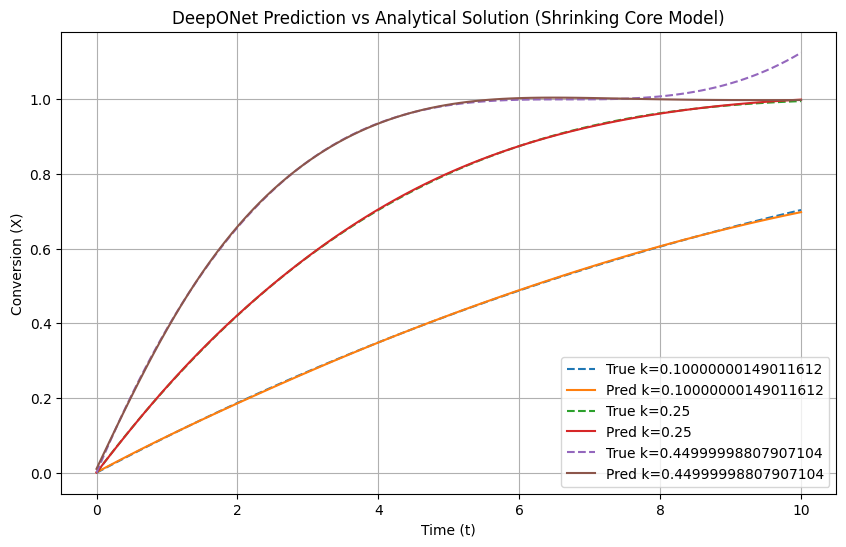

In [23]:
# Visualize results for specific k values
k_val = np.array([[0.1], [0.25], [0.45]]).astype("float32")
y_pred = model.predict((k_val, t_trunk.astype("float32")))

plt.figure(figsize=(10, 6))
for i in range(len(k_val)):
    # Analytical solution for comparison
    y_true = 1 - np.power(1 - k_val[i] * t_trunk / 3, 3)
    plt.plot(t_trunk, y_true, '--', label=f'True k={k_val[i][0]}')
    plt.plot(t_trunk, y_pred[i], '-', label=f'Pred k={k_val[i][0]}')

plt.xlabel('Time (t)')
plt.ylabel('Conversion (X)')
plt.title('DeepONet Prediction vs Analytical Solution (Shrinking Core Model)')
plt.legend()
plt.grid(True)
plt.show()

In [24]:
# DeepXDE Speed Test
import time

# Time to query DeepONet for 500 new k values
start_time = time.time()
y_pred = model.predict((k_test, t_trunk.astype("float32")))
end_time = time.time()
deeponet_time = end_time - start_time
print(f"Time to query DeepONet for 500 new k values: {deeponet_time*1000:.2f} ms")

Time to query DeepONet for 500 new k values: 5.52 ms


In [25]:
# Calculate L2 Relative error for 5 different k values
import deepxde as dde

# 1. Pick 5 random k values within the range [0.05, 0.5]
np.random.seed(10)
k_samples = np.random.uniform(0.05, 0.5, (5, 1)).astype("float32")

# 2. Get DeepONet predictions
y_pred_samples = model.predict((k_samples, t_trunk.astype("float32")))

# 3. Calculate analytical solutions and relative L2 error
print(f"{'k value':<10} | {'L2 Relative Error':<20}")
print("-" * 35)

for i in range(len(k_samples)):
    k_val = k_samples[i][0]
    # True solution
    y_true_sample = 1 - np.power(1 - k_val * t_trunk / 3, 3)
    y_true_sample = y_true_sample.reshape(1, -1) # Match prediction shape (1, 100)

    # Calculate error using DeepXDE utility
    error = dde.metrics.l2_relative_error(y_true_sample, y_pred_samples[i:i+1])

    print(f"{k_val:<10.4f} | {error:<20.4e}")

k value    | L2 Relative Error   
-----------------------------------
0.3971     | 8.5885e-03          
0.0593     | 1.4764e-02          
0.3351     | 3.8457e-03          
0.3870     | 6.1585e-03          
0.2743     | 2.9241e-03          


Here we can see that the conversion is exceeding 1 as it is not the case in actual. We need to tune the model to obey the constrain of $0 < X ≼ 1$

In [26]:
# Re-defining the network with a dimension-safe Sigmoid transformation
net = dde.maps.DeepONetCartesianProd(
    layer_sizes_branch = [1, 64, 64, 100],
    layer_sizes_trunk = [1, 64, 64, 100],
    activation = "tanh",
    kernel_initializer = "Glorot uniform"
)

# Ensure the transformation preserves the shape of the output tensor
net.apply_output_transform(lambda x, y: torch.sigmoid(y))

model = dde.Model(data, net)

print("Retraining with Sigmoid [0, 1] constraint...")
model.compile("adam", lr=1e-3)
model.train(iterations=15000, display_every=2000)

model.compile("L-BFGS-B")
model.train()



Retraining with Sigmoid [0, 1] constraint...
Compiling model...
'compile' took 0.000182 s

Training model...

Step      Train loss    Test loss     Test metric
0         [1.20e-01]    [1.17e-01]    []  
2000      [1.83e-04]    [1.85e-04]    []  
4000      [7.04e-05]    [6.76e-05]    []  
6000      [5.12e-05]    [5.00e-05]    []  
8000      [2.94e-05]    [2.85e-05]    []  
10000     [1.61e-05]    [1.53e-05]    []  
12000     [1.03e-05]    [9.98e-06]    []  
14000     [6.76e-06]    [6.57e-06]    []  
15000     [4.44e-06]    [4.48e-06]    []  

Best model at step 15000:
  train loss: 4.44e-06
  test loss: 4.48e-06
  test metric: []

'train' took 76.525837 s

Compiling model...
'compile' took 0.001415 s

Training model...

Step      Train loss    Test loss     Test metric
15000     [4.44e-06]    [4.48e-06]    []  

Best model at step 15000:
  train loss: 4.44e-06
  test loss: 4.48e-06
  test metric: []

'train' took 0.006549 s



(<deepxde.model.LossHistory at 0x7edf4f37bd10>,
 <deepxde.model.TrainState at 0x7edf4f379cd0>)

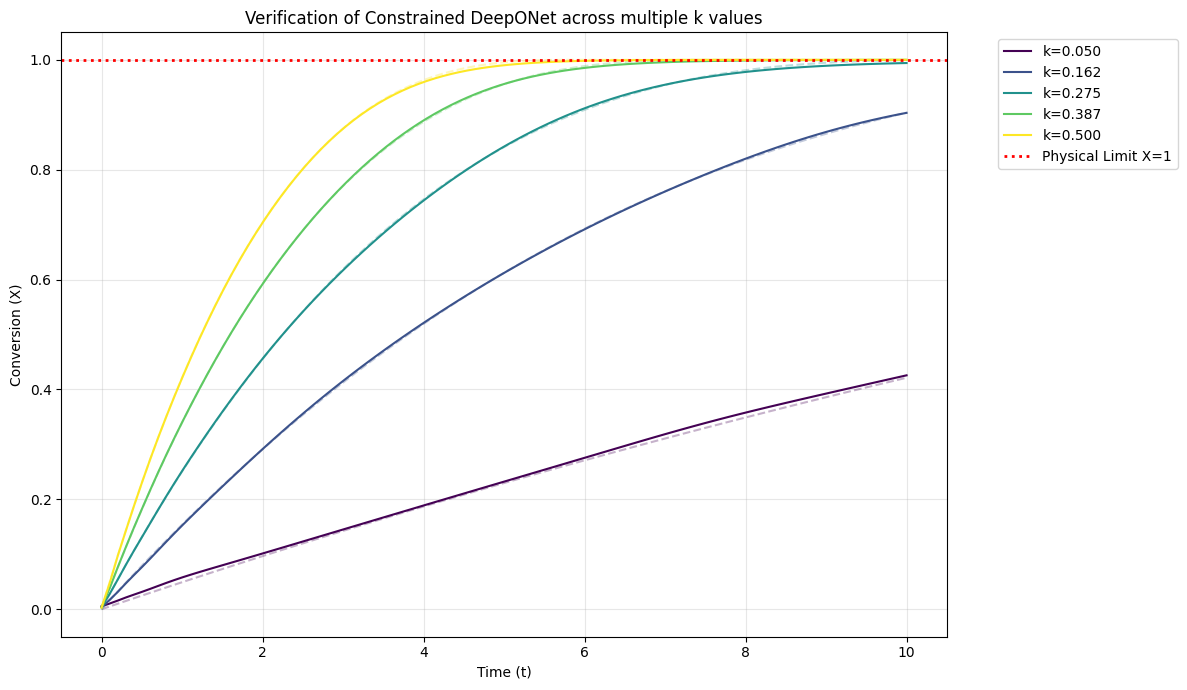

Maximum predicted conversion value: 1.0000


In [27]:
# Ensure t_trunk_fixed is defined since it was removed from the previous cell
t_trunk_fixed = t_trunk.astype("float32")

# 1. Select a broader range of k values (5 samples as requested in latest edit)
k_test_multiple = np.linspace(0.05, 0.5, 5).reshape(-1, 1).astype("float32")

# 2. Predict trajectories using the constrained model
y_pred_multiple = model.predict((k_test_multiple, t_trunk_fixed))

# 3. Plot the results
plt.figure(figsize=(12, 7))
colors = plt.cm.viridis(np.linspace(0, 1, len(k_test_multiple)))

for i in range(len(k_test_multiple)):
    k_val = k_test_multiple[i][0]
    # Analytical comparison (truncated at X=1 naturally by the physics)
    y_true = 1 - np.power(np.maximum(0, 1 - k_val * t_trunk_fixed.flatten() / 3), 3)

    plt.plot(t_trunk_fixed, y_true, '--', color=colors[i], alpha=0.3)
    plt.plot(t_trunk_fixed, y_pred_multiple[i], '-', color=colors[i], label=f'k={k_val:.3f}')

plt.axhline(1, color='red', linewidth=2, linestyle=':', label='Physical Limit X=1')
plt.xlabel('Time (t)')
plt.ylabel('Conversion (X)')
plt.title('Verification of Constrained DeepONet across multiple k values')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print max value found in predictions to confirm bound
print(f"Maximum predicted conversion value: {np.max(y_pred_multiple):.4f}")

## 4. Custom PyTorch Implementation
In this section, we build a native PyTorch version of the DeepONet. This allows for greater flexibility in architecture and training loops while maintaining the same Sigmoid physical constraint.

So, after transforming the output variables obeying the physical constrain, the model predicted the values perfectly

# **Pytorch Implementation**

In [12]:
# import libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

In [13]:
# Generating the data for training the neural operator

torch.manual_seed(42)
np.random.seed(42)

t_trunk = torch.linspace(0, 10, 100).reshape(-1, 1)

k_train = torch.FloatTensor(500, 1).uniform_(0.05, 0.5)
X_train = 1 - np.power(1 - k_train * t_trunk.T / 3, 3)

# Defining the test data
k_test = torch.FloatTensor(500, 1).uniform_(0.05, 0.5)
X_test = 1 - np.power(1 - k_test * t_trunk.T / 3, 3)

# print all the shapes
print("Shape of k_train:", k_train.shape)
print("Shape of X_train:", X_train.shape)
print("Shape of k_test:", k_test.shape)
print("Shape of X_test:", X_test.shape)


Shape of k_train: torch.Size([500, 1])
Shape of X_train: torch.Size([500, 100])
Shape of k_test: torch.Size([500, 1])
Shape of X_test: torch.Size([500, 100])


/tmp/ipykernel_8886/1044612786.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  X_train = 1 - np.power(1 - k_train * t_trunk.T / 3, 3)
/tmp/ipykernel_8886/1044612786.py:13: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  X_test = 1 - np.power(1 - k_test * t_trunk.T / 3, 3)


In [14]:
# Defining the branch net and trunk net

class BranchNet(nn.Module):
  def __init__(self, p=100):
    super().__init__()
    self.fc1 = nn.Linear(1, 64)
    self.fc2 = nn.Linear(64, 64)
    self.fc3 = nn.Linear(64, p)

  def forward(self, k):
    a1 = torch.tanh(self.fc1(k))
    a2 = torch.tanh(self.fc2(a1))
    output = self.fc3(a2)
    return output

class TrunkNet(nn.Module):
  def __init__(self, p = 100):
    super().__init__()
    self.fc1 = nn.Linear(1, 64)
    self.fc2 = nn.Linear(64, 64)
    self.fc3 = nn.Linear(64, p)

  def forward(self, t):
    a1 = torch.tanh(self.fc1(t))
    a2 = torch.tanh(self.fc2(a1))
    output = self.fc3(a2)
    return output

# Combining both the branch and trunk net classes with the [0, 1] constraint
class DeepONet(nn.Module):
  def __init__(self, p=100):
    super().__init__()
    self.branch = BranchNet(p)
    self.trunk = TrunkNet(p)
    self.bias = nn.Parameter(torch.zeros(1))

  def forward(self, k, t):
    b = self.branch(k)
    tau = self.trunk(t)
    # Compute dot product (Cartesian product) and add bias
    out = torch.mm(b, tau.T) + self.bias
    # Enforce conversion range [0, 1]
    return torch.sigmoid(out)

In [15]:
# Initialize the model, loss function, and optimizer
model_pt = DeepONet(p=100)
criterion = nn.MSELoss()
optimizer = optim.Adam(model_pt.parameters(), lr=1e-3)

# Convert training data to tensor once to avoid warnings and speed up training
y_true_tensor = torch.as_tensor(X_train).float()

# Training Loop
num_epochs = 25000
print("Starting training...")
for epoch in range(num_epochs + 1):
    model_pt.train()
    optimizer.zero_grad()

    # Forward pass
    y_pred = model_pt(k_train, t_trunk)

    loss = criterion(y_pred, y_true_tensor)

    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.6e}")

Starting training...
Epoch 0 | Loss: 1.598167e-01
Epoch 500 | Loss: 5.160819e-04
Epoch 1000 | Loss: 4.713527e-04
Epoch 1500 | Loss: 4.276004e-04
Epoch 2000 | Loss: 4.132916e-04
Epoch 2500 | Loss: 3.872601e-04
Epoch 3000 | Loss: 3.759734e-04
Epoch 3500 | Loss: 3.690150e-04
Epoch 4000 | Loss: 3.638523e-04
Epoch 4500 | Loss: 3.601351e-04
Epoch 5000 | Loss: 3.567616e-04
Epoch 5500 | Loss: 3.533033e-04
Epoch 6000 | Loss: 3.512433e-04
Epoch 6500 | Loss: 3.458875e-04
Epoch 7000 | Loss: 3.430924e-04
Epoch 7500 | Loss: 3.386152e-04
Epoch 8000 | Loss: 3.347567e-04
Epoch 8500 | Loss: 3.305287e-04
Epoch 9000 | Loss: 3.272180e-04
Epoch 9500 | Loss: 3.250419e-04
Epoch 10000 | Loss: 3.205388e-04
Epoch 10500 | Loss: 3.186305e-04
Epoch 11000 | Loss: 3.159967e-04
Epoch 11500 | Loss: 3.129783e-04
Epoch 12000 | Loss: 3.088464e-04
Epoch 12500 | Loss: 6.883871e-04
Epoch 13000 | Loss: 3.109397e-04
Epoch 13500 | Loss: 3.382594e-04
Epoch 14000 | Loss: 3.009627e-04
Epoch 14500 | Loss: 2.986689e-04
Epoch 15000 |

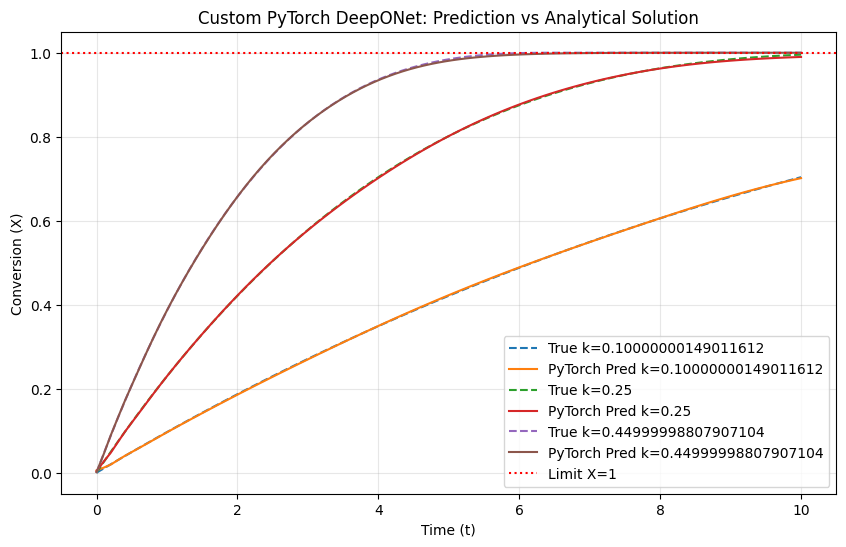

Max predicted value: 1.0000


In [16]:
# Evaluate and Visualize the PyTorch Model
model_pt.eval()
with torch.no_grad():
    # Select test samples
    k_test_samples = torch.tensor([[0.1], [0.25], [0.45]])
    # Predict
    y_pred_pt = model_pt(k_test_samples, t_trunk)

plt.figure(figsize=(10, 6))
for i in range(len(k_test_samples)):
    k_val = k_test_samples[i].item()
    # Analytical solution for comparison
    y_true = 1 - np.power(np.maximum(0, 1 - k_val * t_trunk.numpy() / 3), 3)
    plt.plot(t_trunk.numpy(), y_true, '--', label=f'True k={k_val}')
    plt.plot(t_trunk.numpy(), y_pred_pt[i].numpy(), '-', label=f'PyTorch Pred k={k_val}')

plt.axhline(1, color='red', linestyle=':', label='Limit X=1')
plt.xlabel('Time (t)')
plt.ylabel('Conversion (X)')
plt.title('Custom PyTorch DeepONet: Prediction vs Analytical Solution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Max predicted value: {torch.max(y_pred_pt).item():.4f}")

In [29]:
model_pt.eval()
with torch.no_grad():
    # Ensure inputs are torch tensors
    k_unseen = torch.tensor([[0.12], [0.28], [0.37], [0.44], [0.49]]).float()
    t_trunk_tensor = torch.as_tensor(t_trunk).float()

    X_pred = model_pt(k_unseen, t_trunk_tensor)

    k_np = k_unseen.numpy()
    print("\n── PyTorch Rel L2 on 5 unseen k values ──")
    for i, k_val in enumerate(k_np.flatten()):
        # Analytical calculation for verification
        term = np.maximum(1 - k_val * t_trunk_tensor.numpy() / 3, 0)
        X_true = torch.tensor(1 - term**3).float().squeeze()
        X_true = torch.clamp(X_true, 0, 1)

        rel_l2 = (torch.norm(X_pred[i] - X_true) / torch.norm(X_true)).item() * 100
        print(f"k = {k_val:.2f}: Rel L2 = {rel_l2:.4f}%")


── PyTorch Rel L2 on 5 unseen k values ──
k = 0.12: Rel L2 = 0.3440%
k = 0.28: Rel L2 = 0.2741%
k = 0.37: Rel L2 = 0.1884%
k = 0.44: Rel L2 = 0.1712%
k = 0.49: Rel L2 = 0.2854%
